<font size=6, color='navy'><b>Анализ поведения пользователей приложения магазина продажи продуктов питания</font>

# Введение

<font color='navy'><b>Целевая задача Заказчика</b><i> - оценка влияния изменения шрифтов в мобильном приложении стартапа по продаже продуктов питания на поведение пользователей мобильного приложения</i><br>
<font color='navy'>В рамках реализации целевой задачи пользователей приложения разбили на 3 группы: 2 контрольные со старыми шрифтами и одну экспериментальную — с новыми, для последующего проведения А/А/В-тестирования, необходимого для принятия решения о возможности смены шрифтов без потери количества пользователей

<Font color='navy'><b><i><u>Цели исследования</font>

<font color='navy'>Целями настоящего исследования является <br>- анализ воронки событий - поведение пользователя мобильного приложения; выявление того, на каком этапе существенно падает конверсия пользователей<br>- оценка влияния результатов А/В-тестирования гипотезы о смене шрифтов на поведение пользователей

<Font color='navy'><b><i><u>Задачи исследования</font>

<font color='navy'>Задачами исследования являются<br>- формирование воронки событий<br>- оценка конверсии пользователей по воронке<br> - проверка корректности формирования групп для А/В-тестирования<br> расчет конверсии пользователей по воронке событий

<Font color='navy'><b><i><u>План исследования</b></i></u><br>
<Font color='navy'>1. обзор данных<br>- загрузка библиотек<br>- загрузка и обзор данных<br>2. анализ данных: события, пользователи, период анализ<br>3. формирование и анализ воронки событий <br>4. Анализ результатов А/А/В-тестирования<br>- проверка корректности формирования экспериментальных групп к А/В тесту<br>- анализ результатов А/В-тестирования

# Обзор данных

## Загрузка библиотек

In [1]:
import pandas as pd
import datetime as dt
from scipy import stats as st
import plotly.express as px
from plotly import graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker
import seaborn as sns
pd.set_option('display.max_colwidth', 125)

## Загрузка и обзор файлов с данными

In [3]:
logs = pd.read_csv('C:\\Users\\Svetlana\\DA\\projects\\Online_foodstore\\logs_exp.csv', sep='\t')

In [4]:
logs.info()
logs.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [5]:
# изменим номер эксперимента на номер группы
def group(gr):
    if gr==246:
        return 'A1'
    elif gr==247:
        return 'A2'
    elif gr==248:
        return 'B'
    else:
        return 'UnknownGroup'

logs['ExpId'] = logs['ExpId'].apply(group)
logs

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,A1
1,MainScreenAppear,7416695313311560658,1564053102,A1
2,PaymentScreenSuccessful,3518123091307005509,1564054127,B
3,CartScreenAppear,3518123091307005509,1564054127,B
4,PaymentScreenSuccessful,6217807653094995999,1564055322,B
...,...,...,...,...
244121,MainScreenAppear,4599628364049201812,1565212345,A2
244122,MainScreenAppear,5849806612437486590,1565212439,A1
244123,MainScreenAppear,5746969938801999050,1565212483,A1
244124,MainScreenAppear,5746969938801999050,1565212498,A1


In [6]:
# приведем к стандарту в названиях колонок - уберем заглавные буквы
logs = logs.rename(columns = {'EventName' : 'event_name', \
                             'DeviceIDHash' : 'user_id', \
                             'EventTimestamp' : 'event_time', \
                             'ExpId' : 'group'})
logs.columns

Index(['event_name', 'user_id', 'event_time', 'group'], dtype='object')

In [7]:
# изменим формат данных в колонке event_time
logs['event_time'] = pd.to_datetime(logs['event_time'], unit='s')

In [8]:
# создадим дополнительно колонку с датой события в формате DateTime
logs['event_date'] = logs['event_time'].dt.date

In [9]:
logs.head()

,event_name,user_id,event_time,group,event_date
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,A1,2019-07-25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,A1,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,B,2019-07-25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,B,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,B,2019-07-25


In [10]:
print('Период анализа: с', logs['event_date'].min(), 'по', logs['event_date'].max())

Период анализа: с 2019-07-25 по 2019-08-07


In [11]:
#проверим наличие явных дубликатов записей и при ихналичии посчитаем их процент от всего количества записей
dupl = logs.duplicated().sum()
if dupl != 0:
    print('Выявлено {:,.0f} дубликатов записей'.format(dupl))
    print('Их количество составляет {:.2%} от всех записей'.format(dupl / logs.shape[0]))
else:
    print('Дубликаты записей не выявлены')

Выявлено 413 дубликатов записей
Их количество составляет 0.17% от всех записей


In [12]:
# удалим явные дубликаты
logs = logs.drop_duplicates()

In [13]:
# выведем информацию о файле данных после предобработки
logs.info()
logs.nunique()

<class 'pandas.core.frame.DataFrame'>
Index: 243713 entries, 0 to 244125
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   event_name  243713 non-null  object        
 1   user_id     243713 non-null  int64         
 2   event_time  243713 non-null  datetime64[ns]
 3   group       243713 non-null  object        
 4   event_date  243713 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 11.2+ MB


event_name         5
user_id         7551
event_time    176654
group              3
event_date        14
dtype: int64

## Резюме

<font color='Darkblue'>1. Для исследования предоставлен один датасет с данными о действиях пользователей, с присвоенными им номерами групп, по которым проводилось А/А/В-тестирование - 244,126 записей, за период с 25 июля по 7 августа 2019<br>2. Пропусков в данных нет<br>3. Выявлено 413 дубликатов (0,17% всего количества записей), которые были удалены<br>4. Приведены к стандарту наименования столбцов и изменен формат данных о датах, добавлена колонка с информацией о дате события

# Анализ данных

## Общие данные о событиях и пользователях

In [14]:
# рассчитаем количество и долю пользователей и количество и долю событий по экспериментальным группам
exps_struct = logs.pivot_table(index = 'group', \
                values = ['event_name', 'user_id'], \
                aggfunc = {'event_name':'count', 'user_id':'nunique'}).reset_index()
exps_struct.columns = ['group', 'events_amnt', 'users_amnt']
exps_struct['events_share'] = (exps_struct['events_amnt'] / exps_struct['events_amnt'].sum()).apply(lambda x: f'{x:.2%}')
exps_struct['users_share'] = (exps_struct['users_amnt'] / exps_struct['users_amnt'].sum()).apply(lambda x: f'{x:.2%}')
exps_struct.loc['Total'] = exps_struct.sum(numeric_only=True, axis=0)
exps_struct

,group,events_amnt,users_amnt,events_share,users_share
0,A1,80181.0,2489.0,32.90%,32.96%
1,A2,77950.0,2520.0,31.98%,33.37%
2,B,85582.0,2542.0,35.12%,33.66%
Total,NaN,243713.0,7551.0,NaN,NaN


In [15]:
# посмотрим количество уникальных событий в логе
print('Всего в данных пердставлено {} уникальных событий: {}'.format(logs['event_name'].nunique(), logs['event_name'].unique()))

Всего в данных пердставлено 5 уникальных событий: ['MainScreenAppear' 'PaymentScreenSuccessful' 'CartScreenAppear'
 'OffersScreenAppear' 'Tutorial']


In [16]:
logs['event_name'].value_counts()

event_name
MainScreenAppear           119101
OffersScreenAppear          46808
CartScreenAppear            42668
PaymentScreenSuccessful     34118
Tutorial                     1018
Name: count, dtype: int64

<font color='Darkblue'>Всего в анализируемых данных представлено:<br><b><i> 1. 5 уникальных события, в том числе</b></i><br>&nbsp;&nbsp;&nbsp;- MainScreenAppear, PaymentScreenSuccessful, CartScreenAppear, OffersScreenAppear, Tutorial<br><b><i> 2. общее количество событий - 243,713, в том числе</b></i><br>&nbsp;&nbsp;&nbsp;- 80,181 и 77,950 из контрольных групп<br>&nbsp;&nbsp;&nbsp;- 85,582 из экспериментальной группы <br><b><i>3. 7,551 пользователей, в том числе</b></i><br>&nbsp;&nbsp;&nbsp;- 2,489 и 2,520 контрольных групп<br>&nbsp;&nbsp;&nbsp;- 2,542 из экспериментальной группы<br>
<font color='Darkblue'><i>Распределение событий и пользователей по группам в целом можно признать пропорциональным<br>

In [17]:
print('На одного пользователя приходится в среднем {} события'.format(round(logs.groupby('user_id')['event_name'].agg('count').mean())))
print('Медианное количество событий на одного пользователя составляет {} событий'.format(round(logs.groupby('user_id')['event_name'].agg('count').median())))

На одного пользователя приходится в среднем 32 события
Медианное количество событий на одного пользователя составляет 20 событий


## Период анализа и динамика событий

In [18]:
print('Данные для анализа были сформированы за период с', logs['event_date'].min(), 'по', logs['event_date'].max())

Данные для анализа были сформированы за период с 2019-07-25 по 2019-08-07


In [19]:
logs_by_exp = logs.pivot_table(index='event_date', columns='group', values='event_name', aggfunc='count').reset_index()

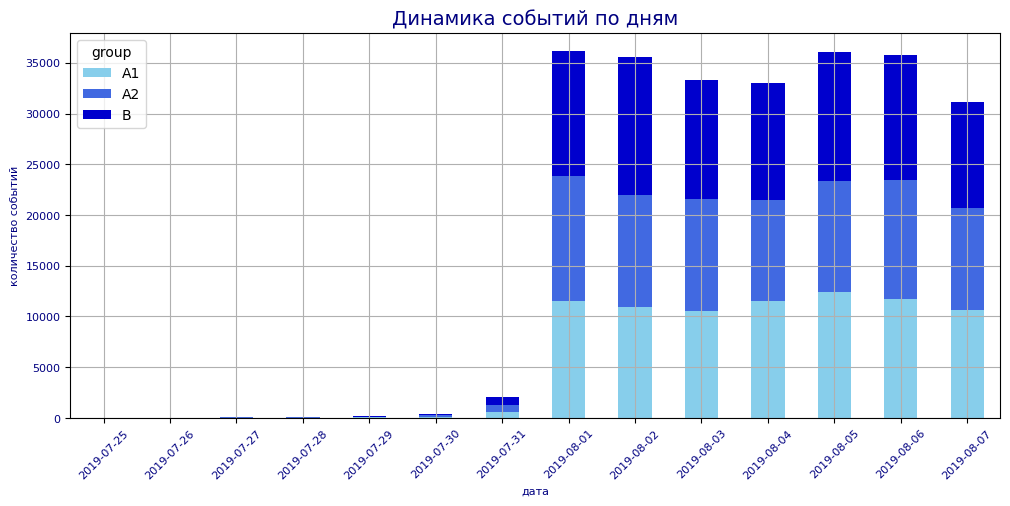

In [20]:
logs_by_exp.plot(x='event_date', y=['A1', 'A2', 'B'], \
                        kind = 'bar', stacked=True, color=['skyblue', 'royalblue', 'mediumblue'], \
                        grid=True,\
                        figsize=(12, 5))

plt.xlabel('дата', color='navy', fontsize=8)
plt.ylabel('количество событий', color='navy', fontsize=8)
plt.title('Динамика событий по дням', color='navy', fontsize=14)
plt.xticks(rotation=45, color='navy', fontsize=8)
plt.yticks(color='navy', fontsize=8)
plt.show;


<font color='Darkblue'>Из представленной гистограммы видно, что<br><b><i> - события регистрируются в основном начиная с 1 августа</b></i><br>- в период с 25 по 30 июля зарегистрировано незначительное количество событий<br>- первый день с более не менее заметным количеством событий - 31 июля<br><i>Динамика количества событий в разрезе групп показывает равномерное распределение количества событий по группам в течение всех дней наблюдений

## Корректировка периода анализа

<font color='Darkblue'><i><u>Проанализируем события, произошедшие <b>до 1 августа

In [24]:
logs_smal_events = logs.query('event_time < "2019-08-01"')
print('За период с 25 по 31 июля зарегистрировано {} событий,'.format(logs_smal_events.shape[0]), 'что составляет {:.2%} от всех событий'. \
      format(logs_smal_events.shape[0] / logs.shape[0]))

За период с 25 по 31 июля зарегистрировано 2826 событий, что составляет 1.16% от всех событий


In [25]:
print('За период с 25 по 31 июля зарегистрировано {} уникальных пользователей,'.format(logs_smal_events['user_id'].count()), 'что составляет {:.2%} от всех пользователей'. \
      format(logs_smal_events['user_id'].nunique() / logs['user_id'].nunique()))

За период с 25 по 31 июля зарегистрировано 2826 уникальных пользователей, что составляет 19.22% от всех пользователей


In [26]:
logs_act = logs.query('event_time >= "2019-08-01"')

In [27]:
print('За период с 25 по 31 июля зарегистрировано {} событий,'.format(logs.shape[0] - logs_act.shape[0]), 'что составляет {:.2%} от всех событий'. \
      format((logs.shape[0] - logs_act.shape[0]) / logs.shape[0]))

За период с 25 по 31 июля зарегистрировано 2826 событий, что составляет 1.16% от всех событий


In [28]:
print('За период с 25 по 31 июля зарегистрировано {} уникальных пользователей,'. \
      format(logs['user_id'].nunique() - logs_act['user_id'].nunique()), 'что составляет {:.2%} от всех пользователей'. \
      format((logs['user_id'].nunique() - logs_act['user_id'].nunique()) / logs['user_id'].nunique()))


За период с 25 по 31 июля зарегистрировано 17 уникальных пользователей, что составляет 0.23% от всех пользователей


In [29]:
logs_act_by_group = logs_act.pivot_table(index='group', values='user_id', aggfunc='nunique').reset_index()
logs_act_by_group.columns = ['group', 'users_amnt']
logs_act_by_group['users_share'] = (logs_act_by_group['users_amnt'] / \
                                    logs_act_by_group['users_amnt'].sum()).apply(lambda x: f'{x:.2%}')
logs_act_by_group


,group,users_amnt,users_share
0,A1,2484,32.97%
1,A2,2513,33.36%
2,B,2537,33.67%


<font color='Darkblue'>С учетом того, что за период с 25 по 31 июля 2019 года<br><i> - произошло 2826 событий, что составляет 1,16% всех событий<br>- 17 уникальных пользователей (0,23% всех пользователей) осущетсвляли покупки в магазине<br>- уникальные пользователи за этот период равномерно представлены пользователями всех экспериментальных групп<br><b><i>возможно далее в анализе использовать данные без учета указанного периода без потери качества общих данных

## Резюме

<font color='Darkblue'>1. В ходе анализа были исследованы данные о <b>243,713 событиях и 7,551 пользователях за период с 25 июля по 07 августа 2019 года</b>, с равномерным распределением как количества событий, так и количества пользователей по группам А/А/В-тестирования<br> - на одного пользователя приходится в среднем 32 события, медианное количество событий на одного пользователя составляет 20 событий<br>3. <b>События регистрируются в основном начиная с 1 августа</b>, динамика количества событий в разрезе групп показывает равномерное распределение количества событий по группам в течении всех дней наблюдений<br>4. С учетом того, что за период с 25 по 31 июля 2019 года произошло 2826 событий (1,16% всех событий) и только 17 уникальных пользователей (0,23% всех пользователей) осуществляли действия в этот период <b>далее в анализе будут использоваться данные за период с 1 августа 2019 года

# Воронка событий

## События

In [30]:
logs_act_by_event = logs_act.pivot_table(index = 'event_name', values = 'user_id', aggfunc={'count', 'nunique'}).reset_index()
logs_act_by_event.columns = ['event_name', 'events_amount', 'users_amount']
logs_act_by_event['events_share'] = (logs_act_by_event['events_amount'] / logs_act_by_event['events_amount'].sum()). \
                                    apply(lambda x: f'{x:.2%}')
logs_act_by_event['users_share'] = (logs_act_by_event['users_amount'] / logs_act_by_event['users_amount'].sum()). \
                                    apply(lambda x: f'{x:.2%}')
logs_act_by_event.style.background_gradient(sns.light_palette("teal", as_cmap=True))

,event_name,events_amount,users_amount,events_share,users_share
0,CartScreenAppear,42303,3734,17.56%,18.55%
1,MainScreenAppear,117328,7419,48.71%,36.86%
2,OffersScreenAppear,46333,4593,19.23%,22.82%
3,PaymentScreenSuccessful,33918,3539,14.08%,17.59%
4,Tutorial,1005,840,0.42%,4.17%


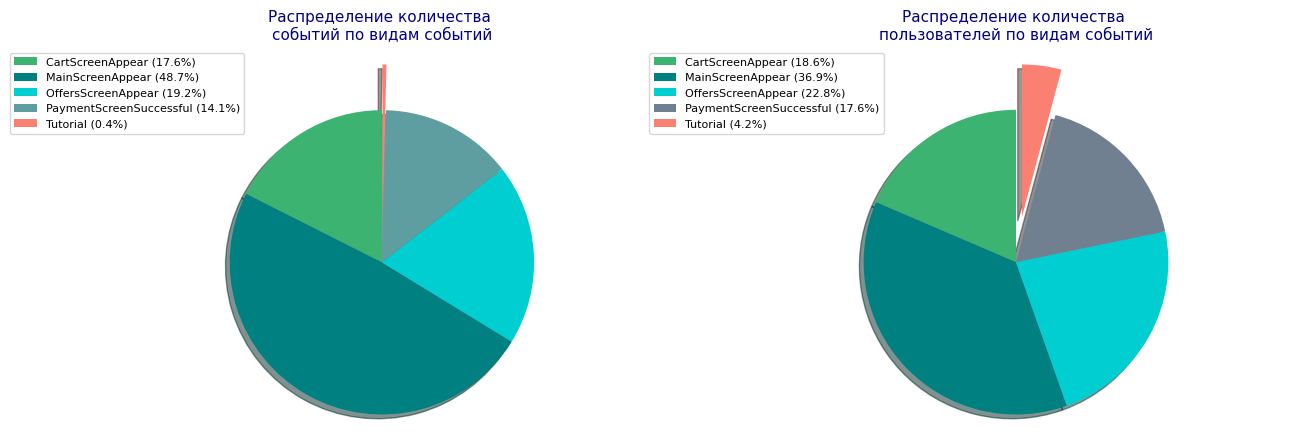

In [31]:
plt.figure(figsize=(15, 5))
ax1 = plt.subplot(1, 2, 1)
events = list(logs_act_by_event['event_name'])
values = logs_act_by_event['events_amount']
total = sum(values)
colors = ['mediumseagreen', 'teal','darkturquoise', 'cadetblue', 'salmon']
explode = [0,0,0,0,0.3]
plt.pie(values, colors=colors, explode=explode, \
        shadow=True, startangle=90, \
        textprops={'fontsize': 10, 'color': 'navy'})
plt.title('Распределение количества \nсобытий по видам событий', fontsize=11, color='navy')
plt.axis('equal')
labels = [f"{n} ({v/total:.1%})" for n,v in zip(events, values)]
plt.legend(
    bbox_to_anchor = (0, 0.75, 0.25, 0.25),
    loc = 'best', labels = labels, fontsize=8 )

ax2 = plt.subplot(1, 2, 2)
events = list(logs_act_by_event['event_name'])
values = logs_act_by_event['users_amount']
total = sum(values)
colors = ['mediumseagreen', 'teal','darkturquoise', 'slategrey', 'salmon']
explode = [0,0,0,0,0.3]
plt.pie(values, colors=colors, explode=explode, \
        shadow=True, startangle=90, \
        textprops={'fontsize': 10, 'color': 'navy'})
plt.title('Распределение количества \nпользователей по видам событий', fontsize=11, color='navy')
plt.axis('equal')
labels = [f"{n} ({v/total:.1%})" for n,v in zip(events, values)]
plt.legend(
    bbox_to_anchor = (0.01, 0.75, 0.25, 0.25),
    loc = 'best', labels = labels, fontsize=8)
plt.show();

<font color='Darkblue'>Из представленных выше данных следует, что<br><b> - наибольшую долю занимает событие - MainScreenAppear как по количеству зарегистрированных событий (117328 раз или 48,7% всех зарегистрированных событий), так и по количеству пользователей, осуществивших это действие (7419 пользователей или 36,9%)</b> <br>- на втором месте как по количеству зарегистрированных событий (46333 раз или  19.2%), так и по количеству пользователей (4593 или 22,8%) расположилось событие OffersScreenAppear<br>- наименьшее как количество зарегистрированных событий (1005 раз или  0,4%), так и количество пользователей (840 или 4,2%) у события Tutorial<br>

<font color='Darkblue'><b><i><u>Заключение</b></i></u><br>Исходя из вышесказанного можно предположить, что <b><i>воронка событий выглядит следующим образом</b></i><br>1. открытие главной страницы приложения (MainScreenAppear)<br>2. выбор товара в каталоге (OffersScreenAppear)<br>3. наполнение корзины товаром (CartScreenAppear)<br>4. оплата товаров из корзины (PaymentScreenSuccessful)<br>✔Событие (Tutorial) - справка/учебник в воронку событий не включается

## Воронка событий

In [32]:
# сформируем таблицу с количеством пользователей на каждом шаге воронки
events_by_user = logs_act.query('event_name != "Tutorial"'). \
                          pivot_table(index='event_name', values='user_id', aggfunc='nunique'). \
                          sort_values(by = 'user_id', ascending = False).reset_index()
events_by_user.columns = ['event_name', 'users_amnt']
# добавим колонку с конверсией в следующий шаг с использованием метода shift
events_by_user['users_to_previouse_step_share'] = (events_by_user['users_amnt'] / events_by_user['users_amnt']. \
                                                        shift(1, fill_value = events_by_user['users_amnt']. \
                                                              loc[events_by_user.index[0]])).apply(lambda x: f'{x:.2%}')
events_by_user['users_to_first_step_share'] = (events_by_user['users_amnt'] / events_by_user['users_amnt']. \
                                                    loc[events_by_user.index[0]]).apply(lambda x: f'{x:.2%}')
events_by_user

,event_name,users_amnt,users_to_previouse_step_share,users_to_first_step_share
0,MainScreenAppear,7419,100.00%,100.00%
1,OffersScreenAppear,4593,61.91%,61.91%
2,CartScreenAppear,3734,81.30%,50.33%
3,PaymentScreenSuccessful,3539,94.78%,47.70%


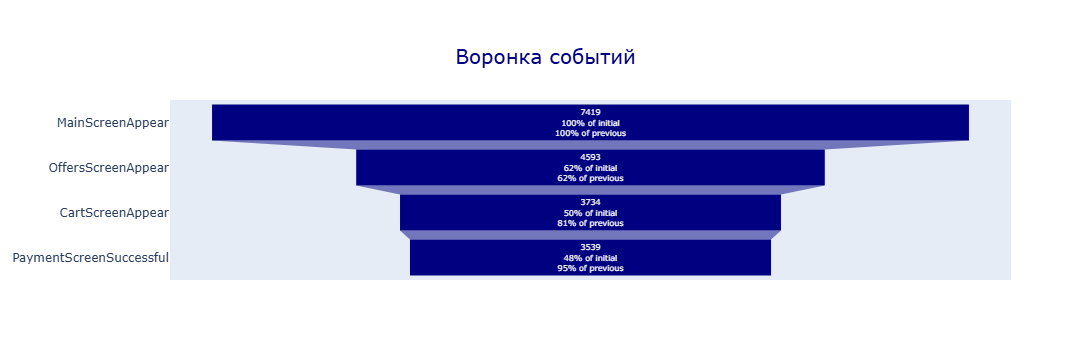

In [33]:
#Визуализируем воронку
fig = go.Figure(go.Funnel(x = events_by_user['users_amnt'], \
                          y = events_by_user['event_name'], \
                          textinfo = 'value+percent initial+percent previous', \
                          marker = {'color': 'navy'}))
fig.update_layout( {'title': {
            'text': 'Воронка событий',
            'x': 0.5,
            'xanchor': 'center',
            'yanchor': 'top',
            'font': {'size': 20},
            'font_color': 'navy'}})
fig.show();

<font color='Darkblue'>Исходя из вышепроведенных расчетов видно, что <br>1. <b><i>больше всего теряется пользователей на этапе перехода с главной страницы (MainScreenAppear) на страницу выбора товара в каталоге (OffersScreenAppear) - 38.1% пользователей</b></i><br>2. до шага оплаты товаров из корзины (PaymentScreenSuccessful) доходит только 47,7% пользователей.

<font color='Darkblue'>Посмотрим сколько пользователей проходит всю воронку от начала до конца

In [34]:
# сформируем таблицу по пользователям, где в колонках будет отражено время посещения страницы
all_steps = logs[logs['event_name'] != 'Tutorial'].pivot_table(index=['user_id', 'group'],\
                                                               columns='event_name', \
                                                               values='event_time', \
                                                               aggfunc='min').reset_index()
# сформируем выборки пользователей, которые поэтапно переходили со страницы на страницу, в соответсвии с воронкой 
step_1 = ~(all_steps['MainScreenAppear'].isna())
step_2 = (step_1) & (all_steps['MainScreenAppear'] < all_steps['OffersScreenAppear'])
step_3 = (step_2) & (all_steps['OffersScreenAppear'] < all_steps['CartScreenAppear'])
step_4 = (step_3) & (all_steps['CartScreenAppear'] < all_steps['PaymentScreenSuccessful'])

# сформируем таблицу, отражающую количество пользователей, последовательно переходящих от шага к шагу воронки
events_by_user_step_by_step = pd.DataFrame( columns = ['event_name', 'users_amnt'], \
                                           data = [['MainScreenAppear',step_1.sum()], \
                                                   ['OffersScreenAppear',step_2.sum()], \
                                                   ['CartScreenAppear',step_3.sum()], \
                                                   ['PaymentScreenSuccessful',step_4.sum()]])
# добавим колонки с конверсией в следующий шаг с использованием метода shift
events_by_user_step_by_step['users_to_previouse_step_share'] = \
        (events_by_user_step_by_step['users_amnt'] / events_by_user_step_by_step['users_amnt']. \
            shift(1, fill_value = events_by_user_step_by_step['users_amnt']. \
            loc[events_by_user_step_by_step.index[0]])).apply(lambda x: f'{x:.2%}')
events_by_user_step_by_step['users_to_first_step_share'] = (events_by_user_step_by_step['users_amnt'] / events_by_user_step_by_step['users_amnt']. \
                                                    loc[events_by_user_step_by_step.index[0]]).apply(lambda x: f'{x:.2%}')
events_by_user_step_by_step

,event_name,users_amnt,users_to_previouse_step_share,users_to_first_step_share
0,MainScreenAppear,7439,100.00%,100.00%
1,OffersScreenAppear,4067,54.67%,54.67%
2,CartScreenAppear,1611,39.61%,21.66%
3,PaymentScreenSuccessful,448,27.81%,6.02%


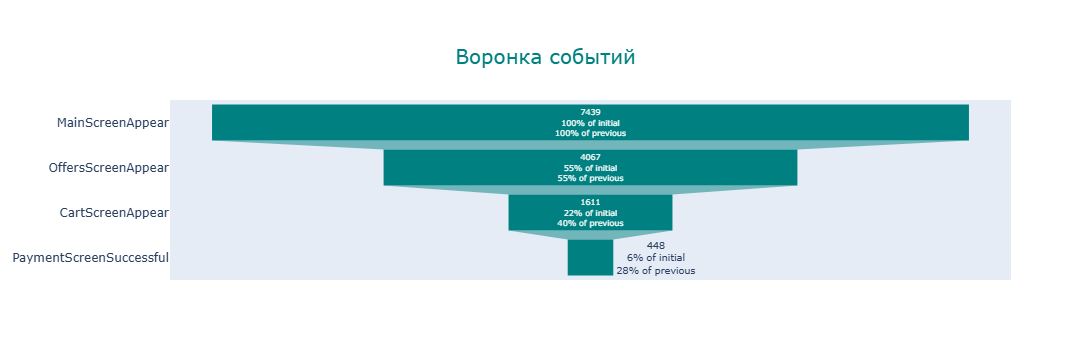

In [35]:
#Визуализируем воронку
fig = go.Figure(go.Funnel(x = events_by_user_step_by_step['users_amnt'], \
                          y = events_by_user_step_by_step['event_name'], \
                          textinfo = 'value+percent initial+percent previous', \
                          marker = {'color': 'teal'}))
fig.update_layout( {'title': {
            'text': 'Воронка событий',
            'x': 0.5,
            'xanchor': 'center',
            'yanchor': 'top',
            'font': {'size': 20},
            'font_color': 'teal'}})
fig.show();

## Резюме

<font color='Darkblue'>Анализ изменения количества пользователей по воронке событий как по всем пользователям, так и с учетом прохождения пользователем всех шагов, показал, что <br>1. <b><i>больше всего теряется пользователей на этапе перехода с главной страницы (MainScreenAppear) на страницу выбора товара в каталоге (OffersScreenAppear)</b> - 38,1% (по всем) и 45% (с учетом прохождения всех шагов) пользователей<br>2. до шага оплаты товаров из корзины (PaymentScreenSuccessful) доходит 47,7% всех пользователей, тогда как <b>среди пользователей, прошедших все шаги воронки - <u>от главной страницы, до оплаты товара дошло только 6% пользователей

# Анализ результатов эксперимента

In [36]:
# сформируем для удобства дальнейшего анализа три набора данных по экспериментальным группам 
group_a1 = logs_act.query('group == "A1"')
group_a2 = logs_act.query('group == "A2"')
group_b = logs_act.query('group == "B"')

In [37]:
# проверим отсутствие пересечения групп по пользователям
print('Выявлено {} пользователей, учетнных одновременно в нескольких группах'. \
      format(len(logs.groupby('user_id')['group'].nunique().reset_index().query('group > 1'))))


Выявлено 0 пользователей, учетнных одновременно в нескольких группах


<font color='Darkblue'><b><i><u>пересечение пользователей по группам не выявлено

## А/А-тест

### Количество пользователей по групам

In [38]:
logs_act_by_group

,group,users_amnt,users_share
0,A1,2484,32.97%
1,A2,2513,33.36%
2,B,2537,33.67%


<font color='Darkblue'>Из таблицы видно, что различие в количестве пользователей между экспериментальными группами составляет менее 1%

In [39]:
results = st.mannwhitneyu(group_a1['user_id'].unique(), group_a2['user_id'].unique())
alpha = 0.05

if results.pvalue < alpha:
    print('Разница в количестве пользователей в группах A1 и A2 статистически значима: p-value - {0:.3f}'.format(results[1]))
else:
    print('Разница в количестве пользователей в группах A1 и A2 статистически НЕ значима: p-value - {0:.3f}'.format(results[1]))

Разница в количестве пользователей в группах A1 и A2 статистически НЕ значима: p-value - 0.698


<font color='Darkblue'><b><i>Комментарий</b><br>Анализ количества пользователей в контрольных группах показал, что <b>различие в количестве пользователей по группам составляет менее 1% и оно <u>статистически не значимо

### Количество событий по группам

In [40]:
events_by_group = logs_act.pivot_table(index='group', values='event_name', aggfunc='count').reset_index()
events_by_group.columns = ['group', 'events_amnt']
events_by_group['events_share'] = (events_by_group['events_amnt'] / events_by_group['events_amnt'].sum()).apply(lambda x: f'{x:.2%}')
events_by_group

,group,events_amnt,events_share
0,A1,79302,32.92%
1,A2,77022,31.97%
2,B,84563,35.10%


<font color='Darkblue'><b><i>Комментарий</b><br>Из таблицы видно, что различие в количестве событий между контрольными группами составляет менее 1%

### Конверсия

1. Проранжируем события по группам в зависимости от количества пользователей, совершивши их
2. Посчитаем долю пользователей, совершивших это соответсвующее событие
3. Проверим: будет ли отличие между группами статистически значимым по всем совершенным событиям

In [41]:
event_by_group = logs_act.query('event_name != "Tutorial"'). \
                          pivot_table(index='event_name', \
                                      columns='group', \
                                      values = 'user_id', \
                                      aggfunc = 'nunique').reset_index()
event_by_group.columns = ['event_name', 'A1', 'A2', 'B']

event_by_group['total'] = event_by_group['A1'] + event_by_group['A2'] + event_by_group['B']
event_by_group = event_by_group.sort_values(by='total', ascending=False)

event_by_group['share_A1'] = (event_by_group['A1'] / event_by_group['A1'].sum()).apply(lambda x: f'{x:.2%}')
event_by_group['share_A2'] = (event_by_group['A2'] / event_by_group['A2'].sum()).apply(lambda x: f'{x:.2%}')
event_by_group['share_B'] = (event_by_group['B'] / event_by_group['B'].sum()).apply(lambda x: f'{x:.2%}')

event_by_group['share_total'] = (event_by_group['total'] / event_by_group['total'].sum()).apply(lambda x: f'{x:.2%}')

event_by_group.style.background_gradient(sns.light_palette("navy", as_cmap=True))

,event_name,A1,A2,B,total,share_A1,share_A2,share_B,share_total
1,MainScreenAppear,2450,2476,2493,7419,37.94%,38.74%,38.74%,38.47%
2,OffersScreenAppear,1542,1520,1531,4593,23.88%,23.78%,23.79%,23.82%
0,CartScreenAppear,1266,1238,1230,3734,19.60%,19.37%,19.11%,19.36%
3,PaymentScreenSuccessful,1200,1158,1181,3539,18.58%,18.12%,18.35%,18.35%


<font color='Darkblue'><b><i>Напишем функцию для определения соотношения доли пользователей совершивших одно и то же событие по группам и оценки статистической значимости разницы между ними

<font color='Darkblue'>Гипотезы, которые быдем проверять в функции:<br><b>H<sub>0</sub></b>  - <b>разницы в долях</b> пользователей, совершивших обытие, <b>нет</b>, действия пользователей  анализируемых групп одинаковы<br><b>H<sub>1</sub></b>  - <b>разница в долях</b> пользователей, совершивших обытие, <b>есть</b>, действия пользователей анализируемых групп отличаются

In [42]:
def rate_ratio(group_1, group_2, event):
#создадим последовательность из количecтва уникальных пользователей совершивших событие в каждом эксперименте 
    users_per_event = np.array([group_1[group_1['event_name'] == event]['user_id'].nunique(), \
                                group_2[group_2['event_name'] == event]['user_id'].nunique()])
        
#создадим последовательность из общего количecтва уникальных пользователей в каждом эксперименте
    users_per_group = np.array([group_1['user_id'].nunique(), group_2['user_id'].nunique()])

# пропорция долей для каждой группы
    rate_ratio_1 = users_per_event[0] / users_per_group[0]
    rate_ratio_2 = users_per_event[1] / users_per_group[1]

# объединенная пропорция долей:
    rate_ratio_combined = (users_per_event[0] + users_per_event[1]) / (users_per_group[0] + users_per_group[1])
# разница пропорций в датасетах
    ratio_difference = rate_ratio_1 - rate_ratio_2
# Z-статистика
    z_value = ratio_difference / math.sqrt(rate_ratio_combined * (1 - rate_ratio_combined) * (1/users_per_group[0] + 1/users_per_group[1]))
#  зададим alpha
    alpha = 0.01
    
# задаем стандартное нормальное распределение (среднее 0, ст.отклонение 1)
    distr = st.norm(0, 1) 
    p_value = (1 - distr.cdf(abs(z_value))) * 2

    if p_value < alpha:
        print('Разница долей между группами статистически значима: p-value - {0:.3f}. \nНулевая гипотеза о равенстве долей отвергнута'.format(p_value))
    else:
        print('Разница долей между группами статистически НЕ значима: p-value - {0:.3f}. \nНулевая гипотеза о равенстве долей не может быть отвергнута'.format(p_value))

<font color='Darkblue'><b><i>Напишем функцию для проверки статистической значимости всех событий

In [43]:
def rate_ratio_by_events(group_1, group_2):
    for event in event_by_group['event_name']:
        print(event)
        rate_ratio(group_1, group_2, event)
        print('')

In [44]:
rate_ratio_by_events(group_a1, group_a2)

MainScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.757. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

OffersScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.248. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

CartScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.229. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

PaymentScreenSuccessful
Разница долей между группами статистически НЕ значима: p-value - 0.115. 
Нулевая гипотеза о равенстве долей не может быть отвергнута



### Резюме

<font color='Darkblue'><b>По результатам A/A тестирования определено</b><br>1. различие в количестве пользователей по группам составляет менее 1% и оно статистически не значимо<br>2. различие в количестве событий между контрольными группами составляет менее 1%<br>3. <b><i>проверка статистической значимости разницы долей пользователей совершивших одно и то же событие между контрольными группами А1 и А2 по всем событиям "воронки событий" показала, что разница долей между группами статистически НЕ значима и нулевая гипотеза о равенстве долей не может быть отвергнута<br><b><i><u>Таким образом, можно утверждать, что А/А-тест прошел успешно.

## А/В-тест

### A1/B-тест

In [45]:
rate_ratio_by_events(group_a1, group_b)

MainScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.295. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

OffersScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.208. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

CartScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.078. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

PaymentScreenSuccessful
Разница долей между группами статистически НЕ значима: p-value - 0.212. 
Нулевая гипотеза о равенстве долей не может быть отвергнута



<font color='Darkblue'><b><i>проверка статитстической значимости разницы долей пользователей совершиивших одно и то же событие между контрольной группой А1 и экспериментальной B по всем событиям "воронки событий" показала, что разница долей между группами статистически НЕ значима и нулевая гипотеза о равенстве долей не может быть отвергнута<br>

### A2/B-тест

In [46]:
rate_ratio_by_events(group_a2, group_b)

MainScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.459. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

OffersScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.920. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

CartScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.579. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

PaymentScreenSuccessful
Разница долей между группами статистически НЕ значима: p-value - 0.737. 
Нулевая гипотеза о равенстве долей не может быть отвергнута



<font color='Darkblue'><b><i>проверка статитстической значимости разницы долей пользователей совершиивших одно и то же событие между контрольной группой А2 и экспериментальной B по всем событиям "воронки событий" показала, что разница долей между группами статистически НЕ значима и нулевая гипотеза о равенстве долей не может быть отвергнута<br>

### (A1+A2)/B-тест

In [47]:
group_a1_a2 = pd.concat([group_a1,group_a2], ignore_index=True)
rate_ratio_by_events(group_a1_a2, group_b)

MainScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.294. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

OffersScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.434. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

CartScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.182. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

PaymentScreenSuccessful
Разница долей между группами статистически НЕ значима: p-value - 0.600. 
Нулевая гипотеза о равенстве долей не может быть отвергнута



<font color='Darkblue'><b><i>проверка статитстической значимости разницы долей пользователей совершиивших одно и то же событие между объединенной контрольной группой (А1 и А2) и экспериментальной группой B по всем событиям "воронки событий" показала, что разница долей между группами статистически НЕ значима и нулевая гипотеза о равенстве долей не может быть отвергнута<br>

### Резюме

<font color='Darkblue'><i>В результате проведения А/В-тестов с уровнем статитистической значимости 0,01 разницы долей пользователей совершивших одно и то же событие между контрольными группами (как по каждой, так и по объединенной) и экспериментальной группой B по всем событиям "воронки событий" показала, что разница долей между группами статистически НЕ значима и нулевая гипотеза о равенстве долей не может быть отвергнута<br><p><b><i><u>Таким образом, можно утверждать, что на поведение пользователей изменение шрифта значимого эффекта не оказало.

<font color='Darkblue'><i>Однако, в ходе проверки гипотез о равенстве долей пользователей, совершивших одно и тоже событие по контрольным и экспериментальной группам, <b>уровень значимости был определен в размере 0.01</b>, что эквивалентно тому, что в мы принимаем риск в 14.85% случаев получить ошибку первого рода.<br> Риск выше 10% можно признать не допустимым. В этой связи применим корректировку Шидока для множественных тестов и оценим результаты тестирования со скорректированным значением порогового значения уровня значимости 

<font color='navy'><b>Изменим функцию расчета статистической значимости с учетом корректировки уровня значимости методом Шидока и ввода уровня alpha и количества экспериментов при задании фукнции

In [48]:
def rate_ratio_corr(group_1, group_2, event, alpha, exp_amnt):
#создадим последовательность из количecтва уникальных пользователей совершивших событие в каждом эксперименте 
    users_per_event = np.array([group_1[group_1['event_name'] == event]['user_id'].nunique(), \
                                group_2[group_2['event_name'] == event]['user_id'].nunique()])
        
#создадим последовательность из общего количecтва уникальных пользователей в каждом эксперименте
    users_per_group = np.array([group_1['user_id'].nunique(), group_2['user_id'].nunique()])

# пропорция долей для каждой группы
    rate_ratio_1 = users_per_event[0] / users_per_group[0]
    rate_ratio_2 = users_per_event[1] / users_per_group[1]

# объединенная пропорция долей:
    rate_ratio_combined = (users_per_event[0] + users_per_event[1]) / (users_per_group[0] + users_per_group[1])
# разница пропорций в датасетах
    ratio_difference = rate_ratio_1 - rate_ratio_2
# Z-статистика
    z_value = ratio_difference / math.sqrt(rate_ratio_combined * (1 - rate_ratio_combined) * (1/users_per_group[0] + 1/users_per_group[1]))
#  зададим alpha
    shidak_alpha = 1 - (1 - alpha)**(1/exp_amnt)
    
# задаем стандартное нормальное распределение (среднее 0, ст.отклонение 1)
    distr = st.norm(0, 1) 
    p_value = (1 - distr.cdf(abs(z_value))) * 2

    if p_value < shidak_alpha:
        print('Разница долей между группами статистически значима: p-value - {0:.3f}. \nНулевая гипотеза о равенстве долей отвергнута'.format(p_value))
    else:
        print('Разница долей между группами статистически НЕ значима: p-value - {0:.3f}. \nНулевая гипотеза о равенстве долей не может быть отвергнута'.format(p_value))

также изменим фукнцию перебора событий, добавив к задаваемым параметрам alpha и количество экспериментов

In [49]:
def rate_ratio_by_events_corr(group_1, group_2, alpha, exp_amnt):
    for event in event_by_group['event_name']:
        print(event)
        rate_ratio(group_1, group_2, event)
        print('')

In [50]:
rate_ratio_by_events_corr(group_a1, group_a2, 0.01, 16)

MainScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.757. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

OffersScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.248. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

CartScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.229. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

PaymentScreenSuccessful
Разница долей между группами статистически НЕ значима: p-value - 0.115. 
Нулевая гипотеза о равенстве долей не может быть отвергнута



In [51]:
rate_ratio_by_events_corr(group_a1, group_b, 0.01, 16)

MainScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.295. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

OffersScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.208. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

CartScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.078. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

PaymentScreenSuccessful
Разница долей между группами статистически НЕ значима: p-value - 0.212. 
Нулевая гипотеза о равенстве долей не может быть отвергнута



In [52]:
rate_ratio_by_events_corr(group_a2, group_b, 0.01, 16)

MainScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.459. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

OffersScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.920. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

CartScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.579. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

PaymentScreenSuccessful
Разница долей между группами статистически НЕ значима: p-value - 0.737. 
Нулевая гипотеза о равенстве долей не может быть отвергнута



In [53]:
rate_ratio_by_events_corr(group_a1_a2, group_b, 0.01, 16)

MainScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.294. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

OffersScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.434. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

CartScreenAppear
Разница долей между группами статистически НЕ значима: p-value - 0.182. 
Нулевая гипотеза о равенстве долей не может быть отвергнута

PaymentScreenSuccessful
Разница долей между группами статистически НЕ значима: p-value - 0.600. 
Нулевая гипотеза о равенстве долей не может быть отвергнута



<font color='Darkblue'><i>Проверка статитстической значимости разницы долей пользователей совершиивших одно и то же событие между объединенной контрольной группой (А1 и А2) и экспериментальной группой B по всем событиям "воронки событий" <u><b>с учетом корректировки уровня значимости при множественных экспериментах методом Шидока</u></b> не изменила результатов проверки без корректировки - <b>разница долей между группами статистически НЕ значима и нулевая гипотеза о равенстве долей не может быть отвергнута<br>

# Заключение

<font color='Darkblue'>1. Для исследования предоставлен один датасет с данными о действиях пользователей, с присвоенными им номерами групп, по которым проводилось А/А/В-тестирование - 244,126 записей, за период с 25 июля по 7 августа 2019<br>2. Выявлено 413 дубликатов (0,17% всего количества записей), которые были удалены<br>

<font color='Darkblue'>3. В ходе анализа были исследованы данные данные о 5 уникальных событиях суммарным количеством <b>243,713 события и 7,551 пользователях за период с 25 июля по 07 августа 2019 года</b>, с равномерным распределением как количества событий, так и количества пользователей по группам А/А/В-тестирования<br> - на одного пользователя приходится в среднем 32 события, медианное количество событий на одного пользователя составляет 20 событий<br>4. <b>События регистрируются в основном начиная с 1 августа</b>, динамика количества событий в разрезе групп показывает равномерное распределение количества событий по группам в течении всех дней наблюдений<br>5. С учетом того, что за период с 25 по 31 июля 2019 года произошло 2826 событий - 1,16% всех событий - и только 17 уникальных пользователей - 0,23% всех пользователей - осуществляли действия в этот период <b>в целях более детального анализа использовались данные за период с 1 августа 2019 года

<font color='Darkblue'>6. Анализ изменения количества пользователей по воронке событий как по всем пользователям, так и с учетом последовательного открытия пользователем всех страниц, показал, что <br>✔<b><i> больше всего теряется пользователей на этапе перехода с главной страницы (MainScreenAppear) на страницу выбора товара в каталоге (OffersScreenAppear)</b> - 38,1% (по всем) и 45% (с учетом прохождения всех шагов) пользователей<br>✔ до шага оплаты товаров из корзины (PaymentScreenSuccessful) доходит 47,7% всех пользователей, тогда как <b>среди пользователей, прошедших все шаги воронки - <u>от главной страницы, до оплаты товара доходит только 6% пользователей

<font color='Darkblue'>7. По результатам A/A тестирования определено<br>- различие в количестве пользователей по группам составляет менее 1%, и оно статистически не значимо<br>- различие в количестве событий между контрольными группами составляет менее 1%<br>- проверка статистической значимости <b>разницы долей пользователей совершивших одно и то же событие между контрольными группами А1 и А2 по всем событиям "воронки событий"</b> показала, что разница долей между группами <b>статистически НЕ значима</b> и нулевая гипотеза о равенстве долей не может быть отвергнута<br><b><i><u>А/А-тест прошел успешно

<font color='Darkblue'><i>8. В результате проведения A/В-тестов <b>разницы долей пользователей совершивших одно и то же событие между контрольными группами (как по каждой, так и по объединенной) и экспериментальной группой B по всем событиям "воронки событий"</b> показала, что разница долей между группами <b>статистически НЕ значима</b> и нулевая гипотеза о равенстве долей не может быть отвергнута<br><p><b><i><u>✔ Таким образом, можно утверждать, что на поведение пользователей изменение шрифта значимого эффекта не оказало.